# Slice Thickness Analysis
Visually compares **thick-slice** (4â€“7 mm, clinical) vs **thin-slice** (<2 mm, isotropic/research) MRI volumes in the `brain_only` dataset.

Key question: do these two acquisition types look different enough to matter for diffusion model training?

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F

DATA_ROOT = Path(r"C:\Users\ayush\Downloads\Brats\brain_only")
random.seed(42)
np.random.seed(42)

# â”€â”€ discover all subjects and tag by z-spacing â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
thick_subjects = []   # z-spacing >= 4 mm
thin_subjects  = []   # z-spacing <  2 mm

for child in sorted(DATA_ROOT.iterdir()):
    nii = child / "t1_brain.nii.gz"
    if not (child.is_dir() and nii.exists()):
        continue
    img   = nib.load(str(nii))
    sh    = tuple(img.header.get_data_shape()[:3])
    z_sp  = float(np.sqrt((img.affine[:3, 2] ** 2).sum()))
    entry = dict(id=child.name, path=nii, shape=sh, z_sp=round(z_sp, 2))
    if z_sp >= 4:
        thick_subjects.append(entry)
    elif z_sp < 2:
        thin_subjects.append(entry)

print(f"Thick-slice subjects (z >= 4 mm) : {len(thick_subjects)}")
print(f"Thin-slice  subjects (z <  2 mm) : {len(thin_subjects)}")

Thick-slice subjects (z >= 4 mm) : 139
Thin-slice  subjects (z <  2 mm) : 71


## 1 Â· Depth Distribution Histogram

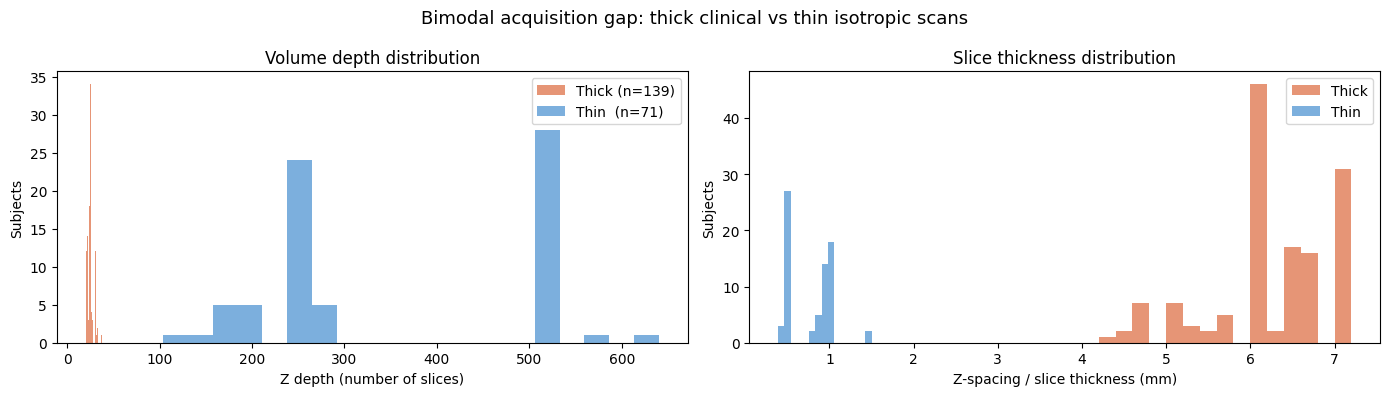

Thick  z-spacing : 4.2 â€“ 7.2 mm  (mean 6.2 mm)
Thin   z-spacing : 0.39 â€“ 1.50 mm  (mean 0.77 mm)


In [2]:
thick_depths   = [e["shape"][2] for e in thick_subjects]
thin_depths    = [e["shape"][2] for e in thin_subjects]
thick_z_sps    = [e["z_sp"]    for e in thick_subjects]
thin_z_sps     = [e["z_sp"]    for e in thin_subjects]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# depth histogram
axes[0].hist(thick_depths, bins=20, color="#e07b54", alpha=0.8, label=f"Thick (n={len(thick_depths)})")
axes[0].hist(thin_depths,  bins=20, color="#5b9bd5", alpha=0.8, label=f"Thin  (n={len(thin_depths)})")
axes[0].set_xlabel("Z depth (number of slices)")
axes[0].set_ylabel("Subjects")
axes[0].set_title("Volume depth distribution")
axes[0].legend()

# z-spacing histogram
axes[1].hist(thick_z_sps, bins=15, color="#e07b54", alpha=0.8, label="Thick")
axes[1].hist(thin_z_sps,  bins=15, color="#5b9bd5", alpha=0.8, label="Thin")
axes[1].set_xlabel("Z-spacing / slice thickness (mm)")
axes[1].set_ylabel("Subjects")
axes[1].set_title("Slice thickness distribution")
axes[1].legend()

fig.suptitle("Bimodal acquisition gap: thick clinical vs thin isotropic scans", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Thick  z-spacing : {min(thick_z_sps):.1f} â€“ {max(thick_z_sps):.1f} mm  (mean {np.mean(thick_z_sps):.1f} mm)")
print(f"Thin   z-spacing : {min(thin_z_sps):.2f} â€“ {max(thin_z_sps):.2f} mm  (mean {np.mean(thin_z_sps):.2f} mm)")

## 2 Â· Side-by-side: raw axial slices (before preprocessing)

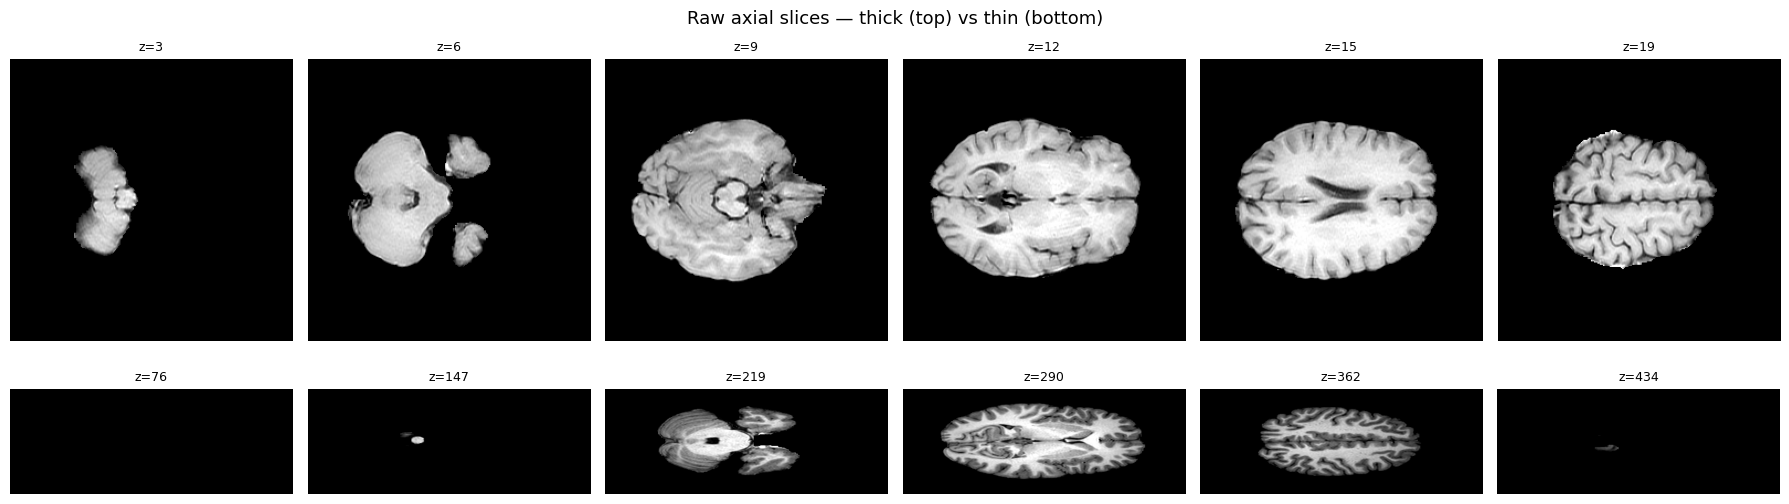

In [3]:
def load_mid_slices(entry, n=6):
    """Load n evenly-spaced axial slices from the middle 70% of a volume."""
    vol = nib.load(str(entry["path"])).get_fdata(dtype=np.float32)
    z   = vol.shape[2]
    z0, z1 = int(z * 0.15), int(z * 0.85)
    indices = np.linspace(z0, z1 - 1, n, dtype=int)
    slices  = [vol[:, :, i] for i in indices]
    # simple robust normalisation for display
    all_px  = np.concatenate([s.ravel() for s in slices])
    nz      = all_px[all_px > 0]
    lo, hi  = (np.percentile(nz, [1, 99]) if nz.size else (0, 1))
    slices  = [np.clip((s - lo) / max(hi - lo, 1e-6), 0, 1) for s in slices]
    return slices, indices

# pick one representative of each type
thick_ex = next(e for e in thick_subjects if e["z_sp"] == 6.0)   # 6 mm thick
thin_ex  = next(e for e in thin_subjects  if e["z_sp"] < 0.5)    # ~0.47 mm thin

t_slices, t_idx = load_mid_slices(thick_ex)
n_slices, n_idx = load_mid_slices(thin_ex)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col in range(6):
    axes[0, col].imshow(t_slices[col], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"z={t_idx[col]}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(n_slices[col], cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title(f"z={n_idx[col]}", fontsize=9)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel(f"THICK\n{thick_ex['id']}\n{thick_ex['z_sp']} mm/slice\ndepth={thick_ex['shape'][2]}",
                      fontsize=9, rotation=0, labelpad=80, va="center")
axes[1, 0].set_ylabel(f"THIN\n{thin_ex['id']}\n{thin_ex['z_sp']} mm/slice\ndepth={thin_ex['shape'][2]}",
                      fontsize=9, rotation=0, labelpad=80, va="center")

fig.suptitle("Raw axial slices â€” thick (top) vs thin (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

## 3 Â· After preprocessing: resized to 256Ã—256

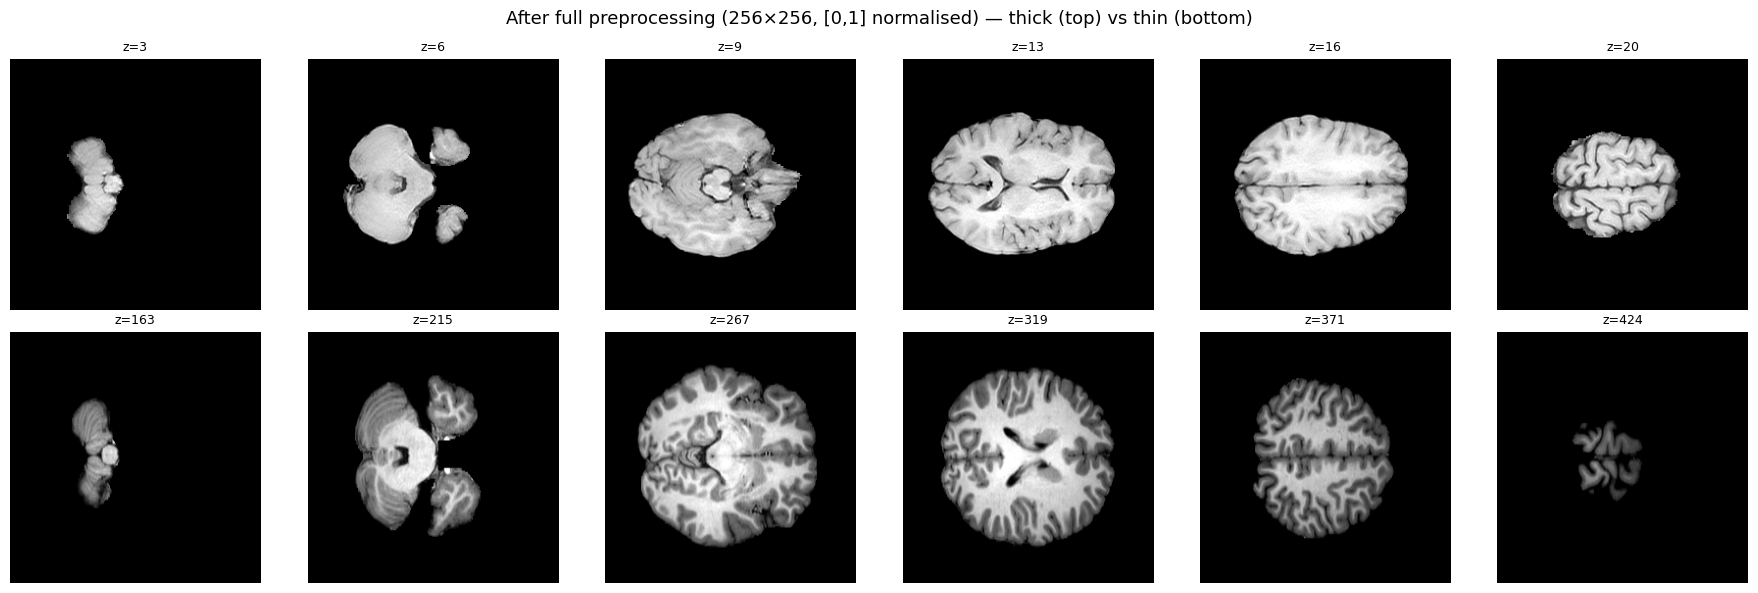

Thick valid slices after pipeline : 6 (from depth 24)
Thin  valid slices after pipeline : 6 (from depth 512)


In [4]:
def preprocess_slices(entry, n=6):
    """Apply full pipeline preprocessing and return n evenly-spaced valid slices."""
    vol    = nib.load(str(entry["path"])).get_fdata(dtype=np.float32)
    nz     = vol[vol != 0]
    if nz.size == 0:
        return [], []
    p05, p995 = np.percentile(nz, [0.5, 99.5])
    norm   = np.clip((vol - p05) / max(p995 - p05, 1e-6), 0., 1.).astype(np.float32)
    z      = norm.shape[2]
    z0, z1 = int(np.floor(z * 0.15)), min(int(np.ceil(z * 0.85)), z)
    valid, vidx = [], []
    for zi in range(z0, z1):
        s = norm[:, :, zi]
        if np.count_nonzero(s) / s.size < 0.05:
            continue
        if s.shape != (256, 256):
            t = torch.from_numpy(s[None, None])
            s = F.interpolate(t, (256, 256), mode="bilinear", align_corners=False).squeeze().numpy()
        valid.append(s)
        vidx.append(zi)
    if not valid:
        return [], []
    picks = np.linspace(0, len(valid) - 1, n, dtype=int)
    return [valid[i] for i in picks], [vidx[i] for i in picks]

t_proc, t_pidx = preprocess_slices(thick_ex)
n_proc, n_pidx = preprocess_slices(thin_ex)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col in range(6):
    axes[0, col].imshow(t_proc[col], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"z={t_pidx[col]}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(n_proc[col], cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title(f"z={n_pidx[col]}", fontsize=9)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel(f"THICK (preprocessed)\n{thick_ex['z_sp']} mm  â†’  256Ã—256",
                      fontsize=9, rotation=0, labelpad=100, va="center")
axes[1, 0].set_ylabel(f"THIN  (preprocessed)\n{thin_ex['z_sp']} mm  â†’  256Ã—256",
                      fontsize=9, rotation=0, labelpad=100, va="center")

fig.suptitle("After full preprocessing (256Ã—256, [0,1] normalised) â€” thick (top) vs thin (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Thick valid slices after pipeline : {len(t_proc)} (from depth {thick_ex['shape'][2]})")
print(f"Thin  valid slices after pipeline : {len(n_proc)} (from depth {thin_ex['shape'][2]})")

## 4 Â· Consecutive-slice gap: what the model 'steps through'

For thick scans, consecutive slices are 6 mm apart â€” a large jump in anatomy.  
For thin scans, consecutive slices are <0.5 mm apart â€” nearly identical neighbours.  
This cell shows 4 consecutive slices from each type to make that concrete.

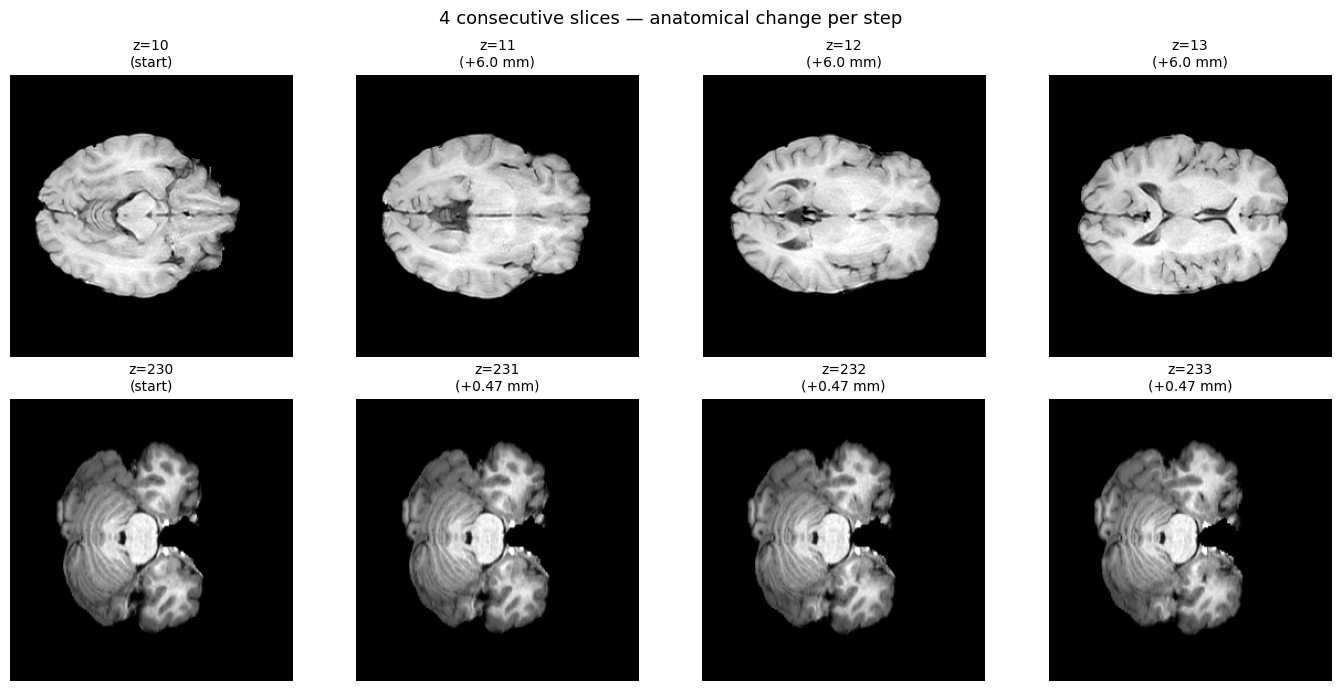

In [5]:
def load_consecutive(entry, start_frac=0.45, n=4):
    """Load n consecutive valid slices starting near start_frac of Z range."""
    vol   = nib.load(str(entry["path"])).get_fdata(dtype=np.float32)
    nz    = vol[vol != 0]
    p05, p995 = np.percentile(nz, [0.5, 99.5])
    norm  = np.clip((vol - p05) / max(p995 - p05, 1e-6), 0., 1.).astype(np.float32)
    z     = norm.shape[2]
    start = int(z * start_frac)
    slices, indices = [], []
    zi = start
    while len(slices) < n and zi < z:
        s = norm[:, :, zi]
        if np.count_nonzero(s) / s.size >= 0.05:
            if s.shape != (256, 256):
                t = torch.from_numpy(s[None, None])
                s = F.interpolate(t, (256, 256), mode="bilinear", align_corners=False).squeeze().numpy()
            slices.append(s)
            indices.append(zi)
        zi += 1
    return slices, indices

t_con, t_cidx = load_consecutive(thick_ex)
n_con, n_cidx = load_consecutive(thin_ex)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col in range(4):
    # thick row
    axes[0, col].imshow(t_con[col], cmap="gray", vmin=0, vmax=1)
    gap = f"+{thick_ex['z_sp']:.1f} mm" if col > 0 else "start"
    axes[0, col].set_title(f"z={t_cidx[col]}\n({gap})", fontsize=10)
    axes[0, col].axis("off")

    # thin row
    axes[1, col].imshow(n_con[col], cmap="gray", vmin=0, vmax=1)
    gap = f"+{thin_ex['z_sp']:.2f} mm" if col > 0 else "start"
    axes[1, col].set_title(f"z={n_cidx[col]}\n({gap})", fontsize=10)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel(f"THICK\n{thick_ex['z_sp']} mm/slice",
                      fontsize=10, rotation=0, labelpad=70, va="center")
axes[1, 0].set_ylabel(f"THIN\n{thin_ex['z_sp']} mm/slice",
                      fontsize=10, rotation=0, labelpad=70, va="center")

fig.suptitle("4 consecutive slices â€” anatomical change per step", fontsize=13)
plt.tight_layout()
plt.show()

## 5 Â· Pixel intensity profiles (sharpness proxy)

A horizontal line profile through the middle of each slice type.  
Thin-slice volumes tend to have sharper tissue boundaries (higher contrast transitions).

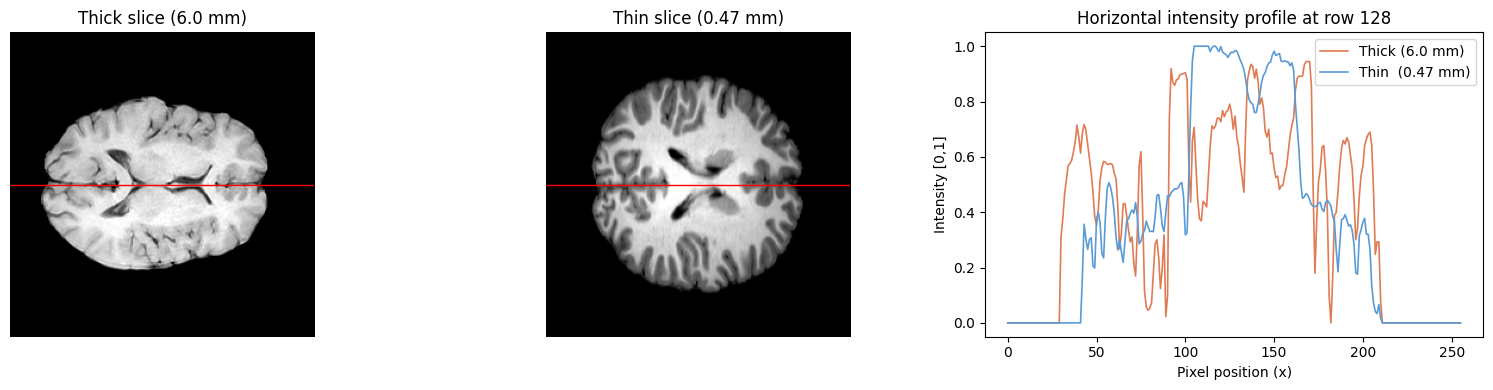

In [6]:
t_mid = t_proc[len(t_proc) // 2]   # middle preprocessed slice (thick)
n_mid = n_proc[len(n_proc) // 2]   # middle preprocessed slice (thin)

row = 128   # horizontal line through the middle

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# side-by-side slices
axes[0].imshow(t_mid, cmap="gray", vmin=0, vmax=1)
axes[0].axhline(row, color="red", linewidth=1)
axes[0].set_title(f"Thick slice ({thick_ex['z_sp']} mm)")
axes[0].axis("off")

axes[1].imshow(n_mid, cmap="gray", vmin=0, vmax=1)
axes[1].axhline(row, color="red", linewidth=1)
axes[1].set_title(f"Thin slice ({thin_ex['z_sp']} mm)")
axes[1].axis("off")

# intensity profile
axes[2].plot(t_mid[row, :], color="#e07b54", label=f"Thick ({thick_ex['z_sp']} mm)", linewidth=1.2)
axes[2].plot(n_mid[row, :], color="#5b9bd5", label=f"Thin  ({thin_ex['z_sp']} mm)",  linewidth=1.2)
axes[2].set_xlabel("Pixel position (x)")
axes[2].set_ylabel("Intensity [0,1]")
axes[2].set_title("Horizontal intensity profile at row 128")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6 Â· Population grid: 4 thick vs 4 thin subjects (3 slices each)

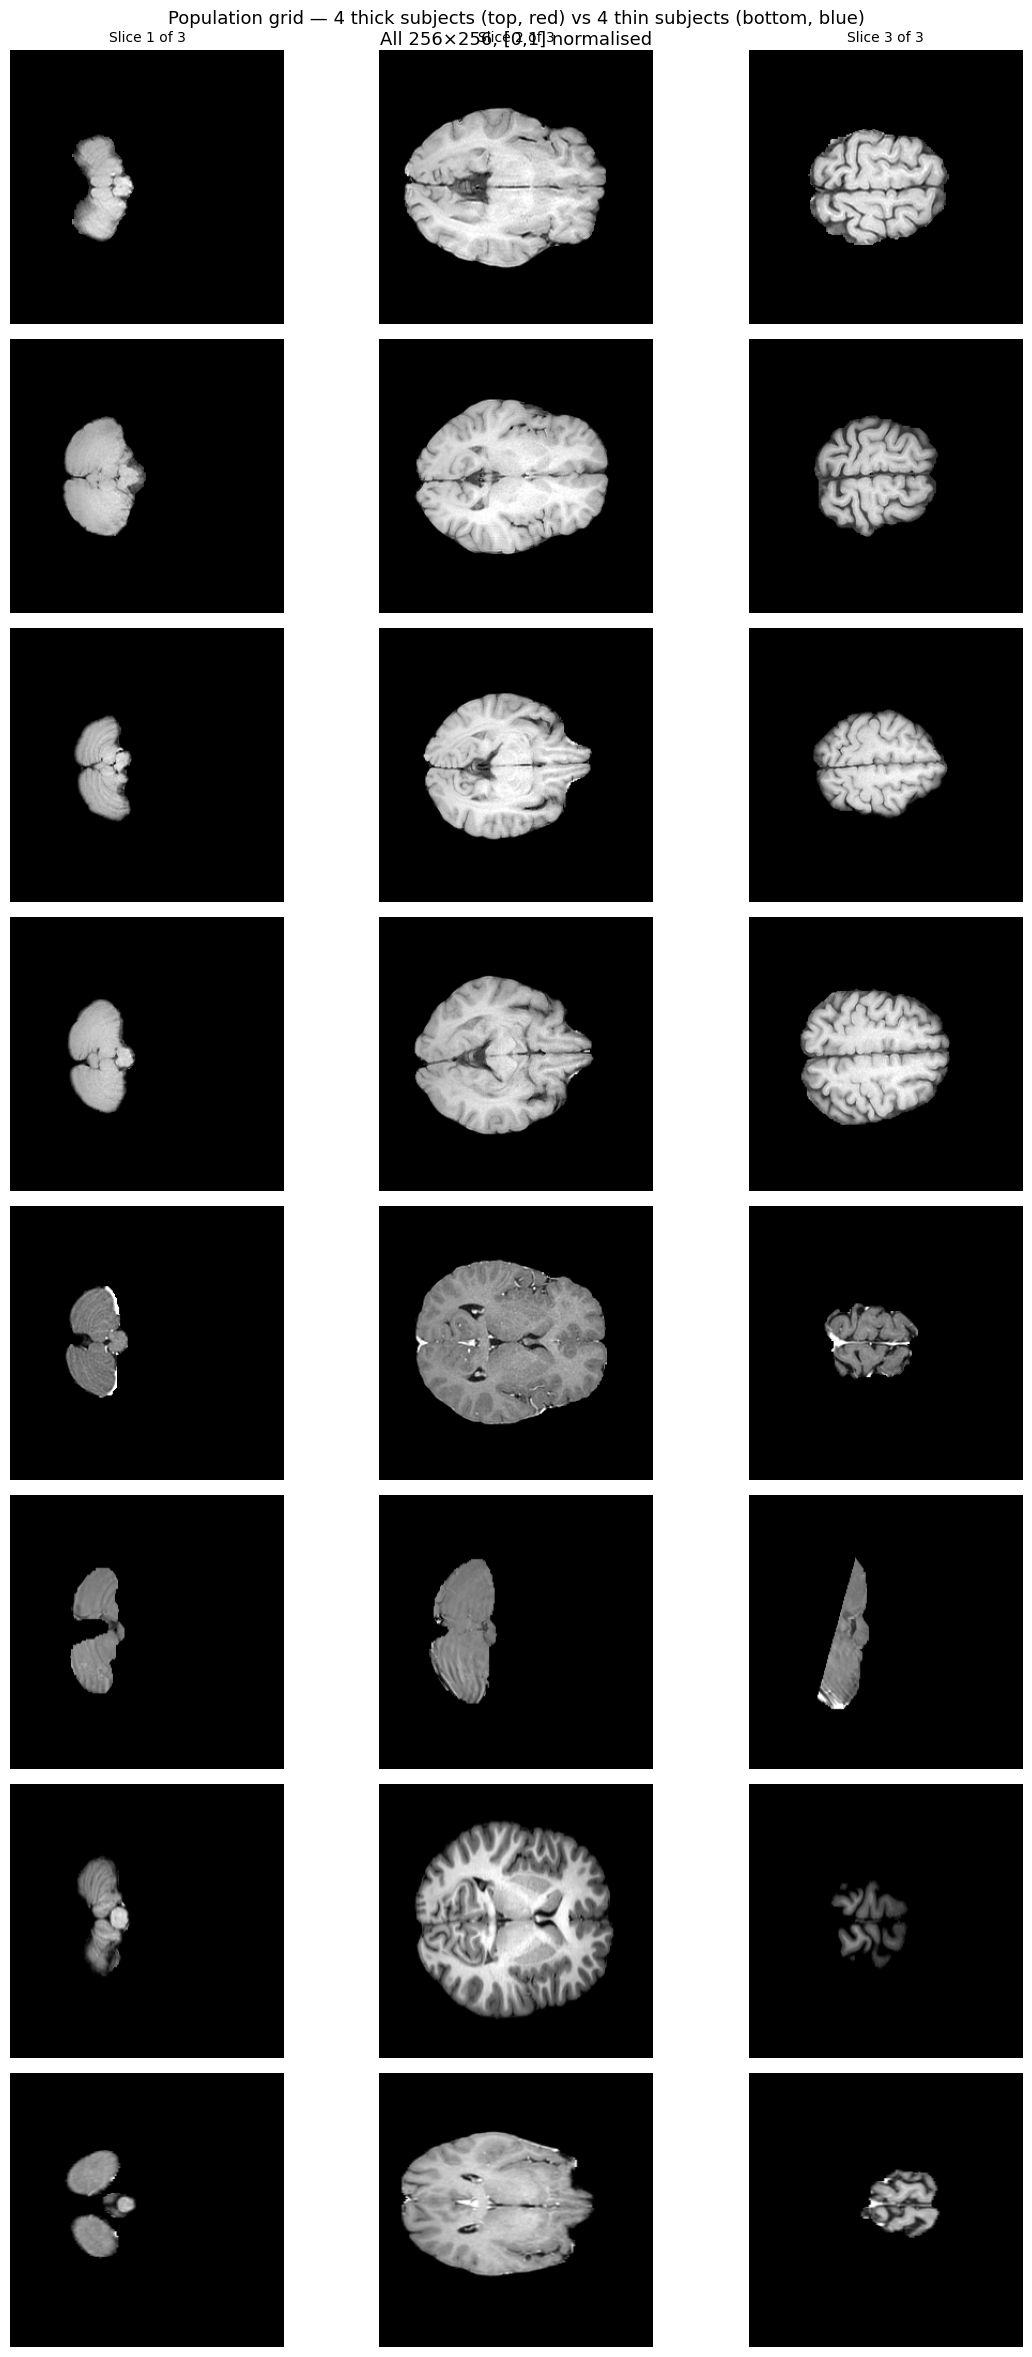

In [7]:
N_SUBJECTS = 4
N_SLICES   = 3

# pick diverse z-spacings for thick examples
thick_picks = []
seen_sp = set()
for e in thick_subjects:
    if e["z_sp"] not in seen_sp:
        thick_picks.append(e)
        seen_sp.add(e["z_sp"])
    if len(thick_picks) == N_SUBJECTS:
        break

thin_picks = []
seen_sp = set()
for e in thin_subjects:
    if e["z_sp"] not in seen_sp:
        thin_picks.append(e)
        seen_sp.add(e["z_sp"])
    if len(thin_picks) == N_SUBJECTS:
        break

rows = N_SUBJECTS * 2
cols = N_SLICES
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))

for i, entry in enumerate(thick_picks):
    slices, _ = preprocess_slices(entry, n=N_SLICES)
    for j, sl in enumerate(slices):
        axes[i, j].imshow(sl, cmap="gray", vmin=0, vmax=1)
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(f"THICK {entry['z_sp']}mm\n{entry['id'][:8]}",
                          fontsize=8, rotation=0, labelpad=85, va="center",
                          color="#c0392b")

for i, entry in enumerate(thin_picks):
    row = N_SUBJECTS + i
    slices, _ = preprocess_slices(entry, n=N_SLICES)
    for j, sl in enumerate(slices):
        axes[row, j].imshow(sl, cmap="gray", vmin=0, vmax=1)
        axes[row, j].axis("off")
    axes[row, 0].set_ylabel(f"THIN {entry['z_sp']}mm\n{entry['id'][:8]}",
                            fontsize=8, rotation=0, labelpad=85, va="center",
                            color="#2471a3")

for j in range(cols):
    axes[0, j].set_title(f"Slice {j+1} of {N_SLICES}", fontsize=10)

fig.suptitle("Population grid â€” 4 thick subjects (top, red) vs 4 thin subjects (bottom, blue)\nAll 256Ã—256, [0,1] normalised",
             fontsize=13)
plt.tight_layout()
plt.show()

## 7 Â· Summary stats per group

Computing valid slice counts per group (takes ~1-2 min)...

                                      THICK         THIN
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Subjects                                139           71
Total valid 2D frames                  2459        12660
Mean frames/subject                    17.7        178.3
Std frames/subject                      2.9         72.9
Median frames/subject                    18          133
Min frames/subject                       14           15
Max frames/subject                       28          315
Avg z-spacing (mm)                      6.2         0.77

Thick subjects contribute 16.3% of all valid frames
Thin  subjects contribute 83.7% of all valid frames


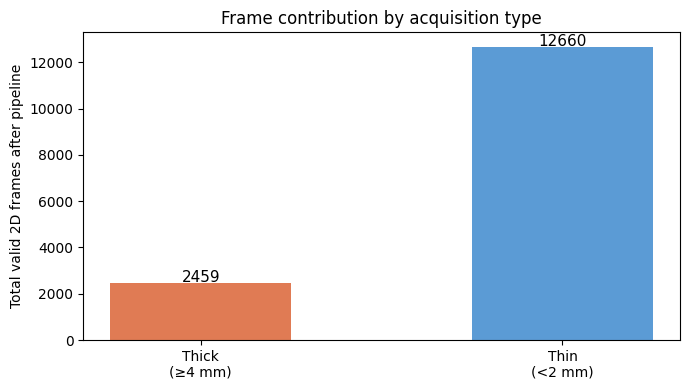

In [8]:
import torch.nn.functional as F

def valid_slice_count(entry):
    vol  = nib.load(str(entry["path"])).get_fdata(dtype=np.float32)
    nz   = vol[vol != 0]
    if nz.size == 0: return 0
    p05, p995 = np.percentile(nz, [0.5, 99.5])
    norm = np.clip((vol - p05) / max(p995 - p05, 1e-6), 0., 1.).astype(np.float32)
    z    = norm.shape[2]
    z0, z1 = int(np.floor(z * 0.15)), min(int(np.ceil(z * 0.85)), z)
    return sum(1 for zi in range(z0, z1)
               if np.count_nonzero(norm[:,:,zi]) / norm[:,:,zi].size >= 0.05)

print("Computing valid slice counts per group (takes ~1-2 min)...")
thick_counts = np.array([valid_slice_count(e) for e in thick_subjects])
thin_counts  = np.array([valid_slice_count(e) for e in thin_subjects])

print(f"\n{'':30s} {'THICK':>12} {'THIN':>12}")
print(f"{'â”€'*54}")
print(f"{'Subjects':30s} {len(thick_counts):>12} {len(thin_counts):>12}")
print(f"{'Total valid 2D frames':30s} {thick_counts.sum():>12} {thin_counts.sum():>12}")
print(f"{'Mean frames/subject':30s} {thick_counts.mean():>12.1f} {thin_counts.mean():>12.1f}")
print(f"{'Std frames/subject':30s} {thick_counts.std():>12.1f} {thin_counts.std():>12.1f}")
print(f"{'Median frames/subject':30s} {int(np.median(thick_counts)):>12} {int(np.median(thin_counts)):>12}")
print(f"{'Min frames/subject':30s} {thick_counts.min():>12} {thin_counts.min():>12}")
print(f"{'Max frames/subject':30s} {thick_counts.max():>12} {thin_counts.max():>12}")
print(f"{'Avg z-spacing (mm)':30s} {np.mean([e['z_sp'] for e in thick_subjects]):>12.1f} {np.mean([e['z_sp'] for e in thin_subjects]):>12.2f}")

total = thick_counts.sum() + thin_counts.sum()
print(f"\nThick subjects contribute {100*thick_counts.sum()/total:.1f}% of all valid frames")
print(f"Thin  subjects contribute {100*thin_counts.sum()/total:.1f}% of all valid frames")

# bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Thick\n(â‰¥4 mm)", "Thin\n(<2 mm)"],
       [thick_counts.sum(), thin_counts.sum()],
       color=["#e07b54", "#5b9bd5"], width=0.5)
ax.set_ylabel("Total valid 2D frames after pipeline")
ax.set_title("Frame contribution by acquisition type")
for i, v in enumerate([thick_counts.sum(), thin_counts.sum()]):
    ax.text(i, v + 50, str(v), ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## 8 · Thin-slice only: fill-rate distribution

Using only the **71 thin-slice subjects** (<2 mm z-spacing).  
For every slice inside the 15%–85% Z window we compute the **fill rate** —
the fraction of non-zero pixels in the 256×256 frame.  
The current pipeline discards slices with fill < 5 %.

In [9]:
# collect fill rates for every candidate slice (thin subjects only)
fill_records = []   # list of dicts: id, z_sp, zi, fill

print(f'Scanning {len(thin_subjects)} thin-slice subjects ...')
for e in thin_subjects:
    vol = nib.load(str(e['path'])).get_fdata(dtype=np.float32)
    nz  = vol[vol != 0]
    if nz.size == 0:
        continue
    p05, p995 = np.percentile(nz, [0.5, 99.5])
    norm = np.clip((vol - p05) / max(p995 - p05, 1e-6), 0., 1.).astype(np.float32)
    z    = norm.shape[2]
    z0   = int(np.floor(z * 0.15))
    z1   = min(int(np.ceil(z * 0.85)), z)
    for zi in range(z0, z1):
        s  = norm[:, :, zi]
        fr = float(np.count_nonzero(s) / s.size)
        fill_records.append(dict(id=e['id'], z_sp=e['z_sp'], zi=zi, fill=fr))

fill_all = np.array([r['fill'] for r in fill_records])
print(f'Total candidate slices (15-85% window) : {len(fill_all)}')
print(f'Fill rate  min/max/mean/median : '
      f'{fill_all.min():.3f} / {fill_all.max():.3f} / '
      f'{fill_all.mean():.3f} / {np.median(fill_all):.3f}')
print(f'Std                            : {fill_all.std():.3f}')
print(f'Dropped by 5% threshold        : {(fill_all < 0.05).sum()} '
      f'({100*(fill_all < 0.05).mean():.1f}%)')
print(f'Retained after 5% filter       : {(fill_all >= 0.05).sum()}')


Scanning 71 thin-slice subjects ...
Total candidate slices (15-85% window) : 17594
Fill rate  min/max/mean/median : 0.000 / 0.458 / 0.185 / 0.187
Std                            : 0.146
Dropped by 5% threshold        : 4934 (28.0%)
Retained after 5% filter       : 12660


### 8a · Overall fill-rate histogram

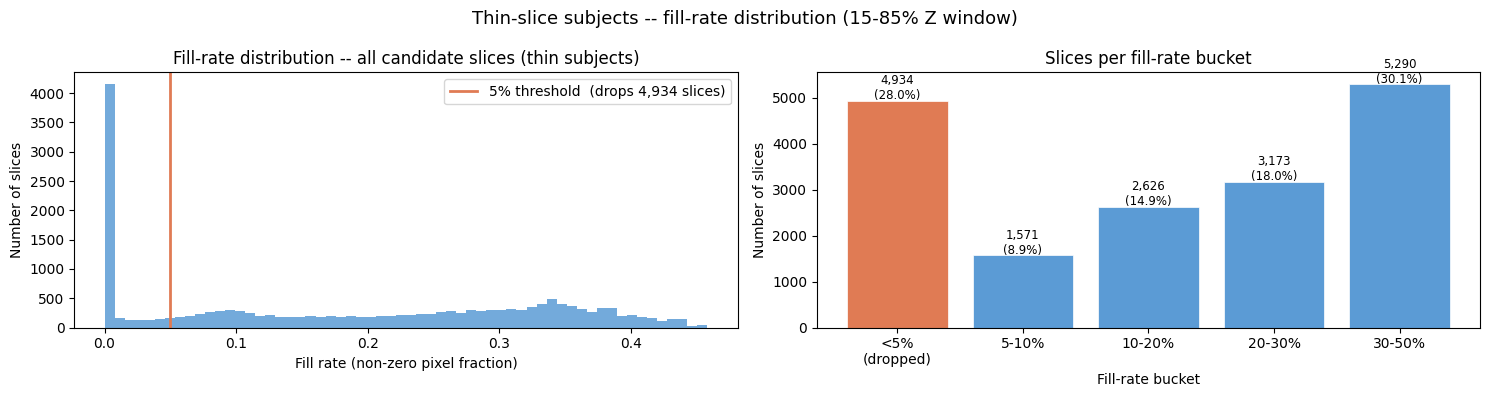

In [10]:
THRESHOLD = 0.05
dropped = fill_all[fill_all < THRESHOLD]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# left: full histogram
axes[0].hist(fill_all, bins=60, color='#5b9bd5', edgecolor='none', alpha=0.85)
axes[0].axvline(THRESHOLD, color='#e07b54', linewidth=2,
                label=f'5% threshold  (drops {len(dropped):,} slices)')
axes[0].set_xlabel('Fill rate (non-zero pixel fraction)')
axes[0].set_ylabel('Number of slices')
axes[0].set_title('Fill-rate distribution -- all candidate slices (thin subjects)')
axes[0].legend()

# right: bucket bar chart
buckets  = [(0, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, 0.30), (0.30, 0.50)]
blabels  = ['<5%\n(dropped)', '5-10%', '10-20%', '20-30%', '30-50%']
bcounts  = [((fill_all >= lo) & (fill_all < hi)).sum() for lo, hi in buckets]
bcolors  = ['#e07b54'] + ['#5b9bd5'] * 4
axes[1].bar(blabels, bcounts, color=bcolors, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Fill-rate bucket')
axes[1].set_ylabel('Number of slices')
axes[1].set_title('Slices per fill-rate bucket')
for i, c in enumerate(bcounts):
    axes[1].text(i, c + 40, f'{c:,}\n({100*c/len(fill_all):.1f}%)',
                 ha='center', fontsize=8.5)

fig.suptitle('Thin-slice subjects -- fill-rate distribution (15-85% Z window)', fontsize=13)
plt.tight_layout()
plt.show()


### 8b · Per-subject fill-rate box plot
Each box = one subject's spread across all its candidate slices.  
Sorted by median fill rate.

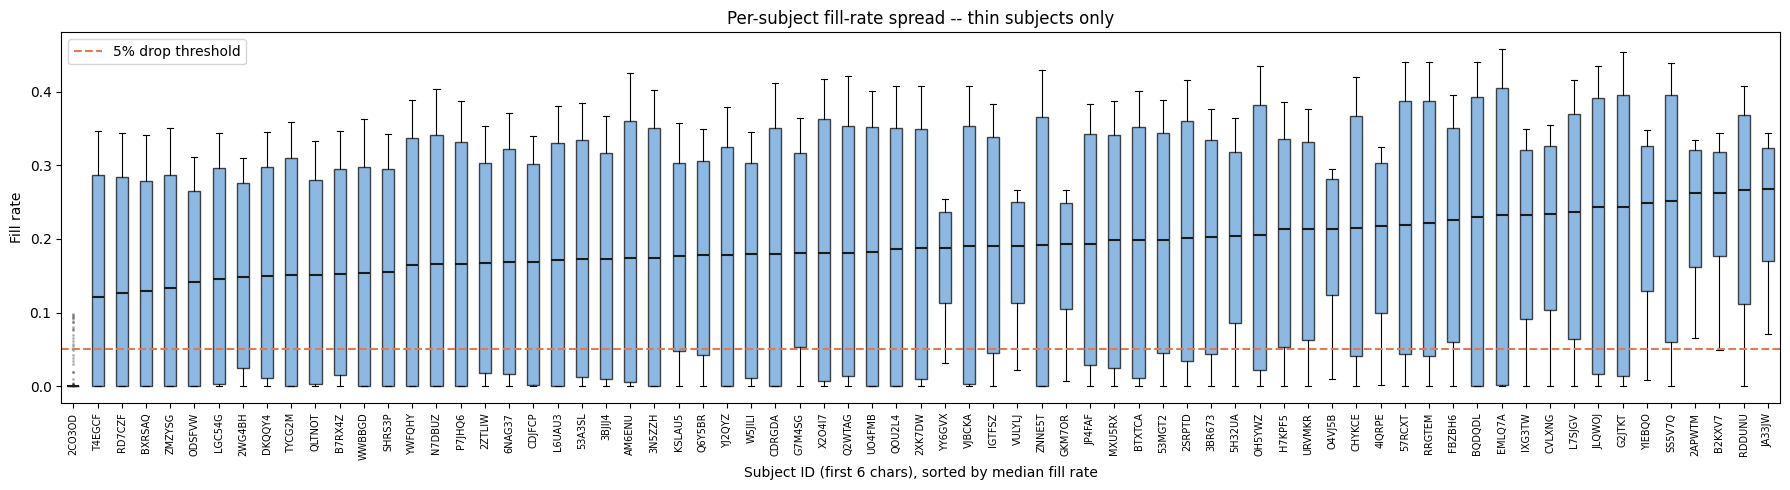

Subjects with median fill < 5%: 1
  2CO3ODNYCK  median=0.000


In [11]:
from collections import defaultdict

subj_map = defaultdict(list)
for r in fill_records:
    subj_map[r['id']].append(r['fill'])

sorted_subjs = sorted(subj_map.items(), key=lambda x: np.median(x[1]))
box_labels   = [s[:6] for s, _ in sorted_subjs]
box_data     = [f     for _, f in sorted_subjs]

fig, ax = plt.subplots(figsize=(18, 5))
ax.boxplot(box_data, patch_artist=True,
           boxprops=dict(facecolor='#5b9bd5', alpha=0.7),
           medianprops=dict(color='#1a1a1a', linewidth=1.5),
           flierprops=dict(marker='.', markersize=2, alpha=0.3),
           whiskerprops=dict(linewidth=0.8),
           capprops=dict(linewidth=0.8))
ax.axhline(0.05, color='#e07b54', linewidth=1.5, linestyle='--',
           label='5% drop threshold')
ax.set_xticks(range(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels, rotation=90, fontsize=7)
ax.set_xlabel('Subject ID (first 6 chars), sorted by median fill rate')
ax.set_ylabel('Fill rate')
ax.set_title('Per-subject fill-rate spread -- thin subjects only')
ax.legend()
plt.tight_layout()
plt.show()

low = [(s, np.median(f)) for s, f in sorted_subjs if np.median(f) < 0.05]
if low:
    print(f'Subjects with median fill < 5%: {len(low)}')
    for s, med in low:
        print(f'  {s}  median={med:.3f}')
else:
    print('No subjects have median fill below 5% -- all contribute retained slices.')


### 8c · Example slices at each fill-rate tier
LOW (5–10 %), MID (20–30 %), HIGH (>35 %) — what does each fill level look like?

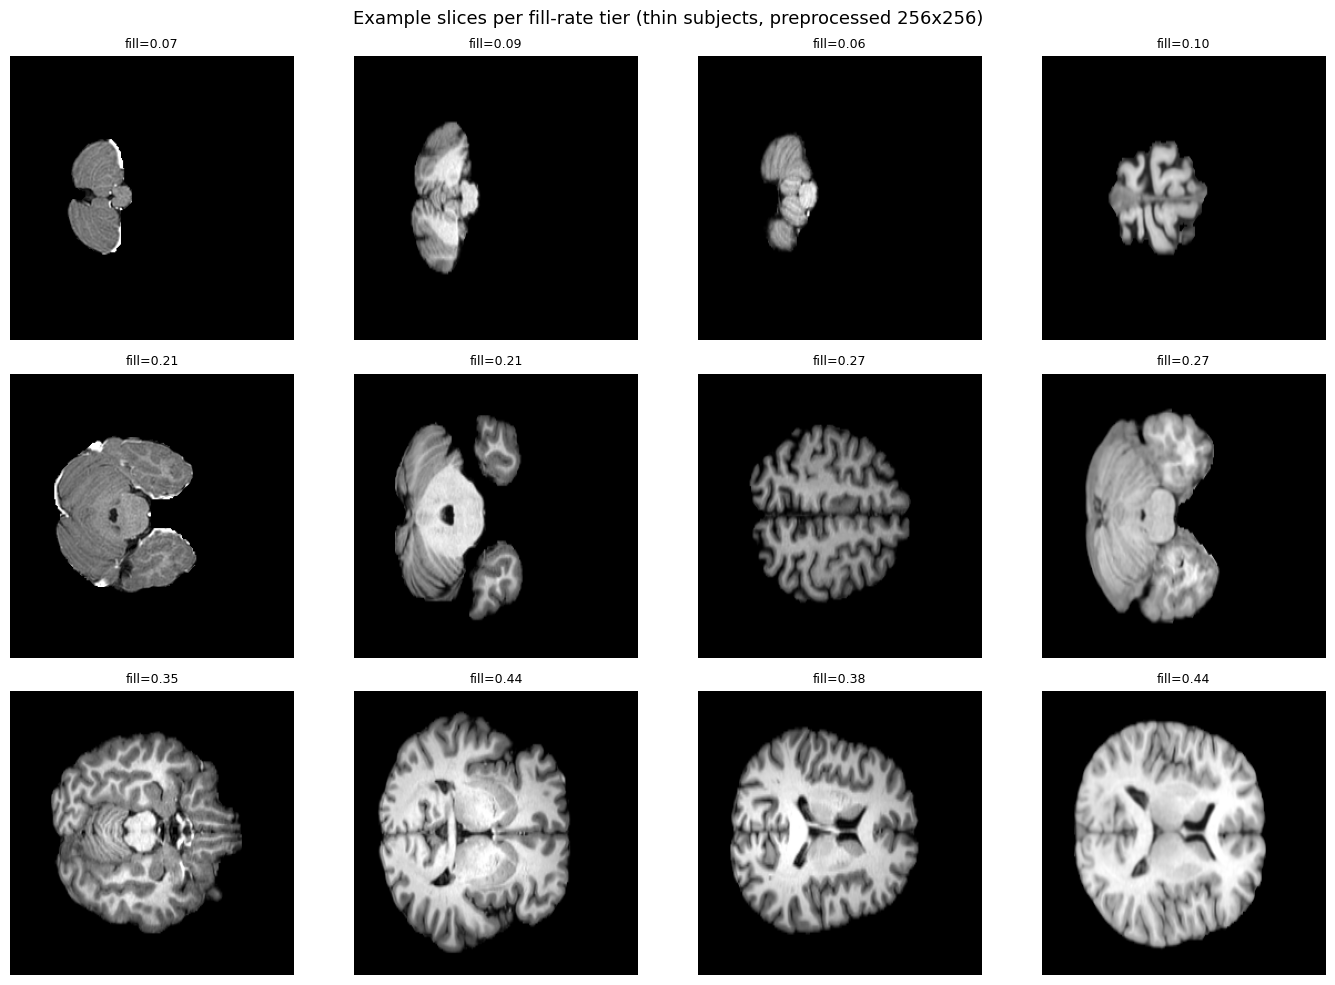

In [12]:
import torch
import torch.nn.functional as F

def load_and_resize(record):
    vol  = nib.load(str(DATA_ROOT / record['id'] / 't1_brain.nii.gz')).get_fdata(dtype=np.float32)
    nz   = vol[vol != 0]
    p05, p995 = np.percentile(nz, [0.5, 99.5])
    norm = np.clip((vol - p05) / max(p995 - p05, 1e-6), 0., 1.).astype(np.float32)
    s    = norm[:, :, record['zi']]
    if s.shape != (256, 256):
        t = torch.from_numpy(s[None, None])
        s = F.interpolate(t, (256, 256), mode='bilinear', align_corners=False).squeeze().numpy()
    return s

tiers = {
    'LOW  (5-10%)' : [r for r in fill_records if 0.05 <= r['fill'] < 0.10],
    'MID  (20-30%)': [r for r in fill_records if 0.20 <= r['fill'] < 0.30],
    'HIGH (>35%)'  : [r for r in fill_records if r['fill'] > 0.35],
}

N = 4
fig, axes = plt.subplots(len(tiers), N, figsize=(14, 10))
for row_i, (label, recs) in enumerate(tiers.items()):
    step  = max(1, len(recs) // N)
    picks = recs[::step][:N]
    for col_j, rec in enumerate(picks):
        sl = load_and_resize(rec)
        axes[row_i, col_j].imshow(sl, cmap='gray', vmin=0, vmax=1)
        axes[row_i, col_j].set_title(f"fill={rec['fill']:.2f}", fontsize=9)
        axes[row_i, col_j].axis('off')
    axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=0, labelpad=90, va='center')

fig.suptitle('Example slices per fill-rate tier (thin subjects, preprocessed 256x256)', fontsize=13)
plt.tight_layout()
plt.show()


### 8d · Summary table

In [13]:
print('=' * 58)
print('  THIN-SLICE FILL RATE SUMMARY (15-85% Z window)')
print('=' * 58)
print(f'  Subjects analysed          : {len(thin_subjects)}')
print(f'  Total candidate slices     : {len(fill_all):>7,}')
print()
print('  Fill rate (all candidates)')
print(f'    Min    : {fill_all.min():.3f}')
print(f'    Max    : {fill_all.max():.3f}  (brain never fills >50% of frame)')
print(f'    Mean   : {fill_all.mean():.3f}')
print(f'    Median : {np.median(fill_all):.3f}')
print(f'    Std    : {fill_all.std():.3f}')
print()
rows = [
    (0,    .05,  '<5%  (DROPPED)'),
    (.05,  .10,  '5-10%'),
    (.10,  .20,  '10-20%'),
    (.20,  .30,  '20-30%'),
    (.30,  .50,  '30-50%'),
    (.50,  1.01, '>50%'),
]
for lo, hi, lbl in rows:
    n = ((fill_all >= lo) & (fill_all < hi)).sum()
    print(f'  {lbl:20s} : {n:>6,}  ({100*n/len(fill_all):5.1f}%)')
print()
kept = (fill_all >= 0.05).sum()
print(f'  Retained after 5% filter   : {kept:>7,}  ({100*kept/len(fill_all):.1f}%)')
print(f'  Dropped  by  5% filter     : {len(fill_all)-kept:>7,}  ({100*(len(fill_all)-kept)/len(fill_all):.1f}%)')


  THIN-SLICE FILL RATE SUMMARY (15-85% Z window)
  Subjects analysed          : 71
  Total candidate slices     :  17,594

  Fill rate (all candidates)
    Min    : 0.000
    Max    : 0.458  (brain never fills >50% of frame)
    Mean   : 0.185
    Median : 0.187
    Std    : 0.146

  <5%  (DROPPED)       :  4,934  ( 28.0%)
  5-10%                :  1,571  (  8.9%)
  10-20%               :  2,626  ( 14.9%)
  20-30%               :  3,173  ( 18.0%)
  30-50%               :  5,290  ( 30.1%)
  >50%                 :      0  (  0.0%)

  Retained after 5% filter   :  12,660  (72.0%)
  Dropped  by  5% filter     :   4,934  (28.0%)
